# Классификация товаров по названиям

## 1. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

c:\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Загрузка данных

In [2]:
train_df = pd.read_csv('../data/raw/train_supervised_dataset.csv')
test_df = pd.read_csv('../data/raw/test_dataset.csv')
print(f'Обучающая выборка: {train_df.shape}')
print(f'Тестовая выборка: {test_df.shape}')

Обучающая выборка: (25000, 4)
Тестовая выборка: (5000, 2)


In [3]:
def preprocess_text(text):
    text = str(text).lower()
    text = __import__("re").sub(r"\s+", " ", text).strip()
    tokens = [w for w in text.split() if len(w) > 1]
    return " ".join(tokens)

train_df["name"] = train_df["name"].apply(preprocess_text)
test_df["name"] = test_df["name"].apply(preprocess_text)
print("Пример после предобработки:")
print(train_df[["name", "good"]].head(3))


Пример после предобработки:
                                    name      good
0  petmax бантик леопард красн розой 2шт    бантик
1       87191 бусы для елки шарики_87191      бусы
2     футболка piazza italia wr011446881  футболка


## 3. Исследование данных (EDA)

In [4]:
print('Колонки:', list(train_df.columns))
print(f'Уникальных категорий (good): {train_df["good"].nunique()}')
print(f'Заполнено брендов: {train_df["brand"].notna().sum()} из {len(train_df)}')
train_df.head()

Колонки: ['id', 'name', 'good', 'brand']
Уникальных категорий (good): 2819
Заполнено брендов: 16495 из 25000


,id,name,good,brand
0,0,petmax бантик леопард красн розой 2шт,бантик,petmax
1,1,87191 бусы для елки шарики_87191,бусы,NaN
2,2,футболка piazza italia wr011446881,футболка,piazza italia
3,3,7) yi572-03x-one заколка для волос для девочки,заколка,NaN
4,4,одежда (вес) 1500,одежда,NaN


In [5]:
print('Топ-20 категорий:')
print(train_df['good'].value_counts().head(20))

Топ-20 категорий:
good
брюки        339
пиво         327
вода         308
печенье      291
таблетки     271
сыр          266
чай          266
масло        247
напиток      232
носки        221
шоколад      218
мороженое    215
сигареты     211
молоко       202
йогурт       189
лампа        187
корм         177
платье       171
сок          170
трусы        166
Name: count, dtype: int64


## 4. Кластеризация + частотный порог

In [8]:
cats = train_df['good'].dropna().unique().astype(str)
print(f'Уникальных категорий для кластеризации: {len(cats)}')

Уникальных категорий для кластеризации: 2819


In [9]:
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print('Модель загружена')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7363.95it/s]


Модель загружена


In [10]:
embeddings = model.encode(cats, show_progress_bar=True, convert_to_numpy=True)
emb_norm = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
print(f'Размерность эмбеддингов: {embeddings.shape}')

Batches: 100%|██████████| 89/89 [00:03<00:00, 26.32it/s]

Размерность эмбеддингов: (2819, 384)


In [11]:
N_CLUSTERS = 100
MIN_ITEMS = 200

km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init='auto')
cluster_labels_km = km.fit_predict(emb_norm)
print(f'Сформировано кластеров: {len(set(cluster_labels_km))}')

Сформировано кластеров: 100


In [13]:
cat_count_map = train_df['good'].value_counts().to_dict()
cluster_item_counts = Counter()
for cat, label in zip(cats, cluster_labels_km):
    cluster_item_counts[label] += cat_count_map.get(cat, 0)

small_clusters = {l for l, c in cluster_item_counts.items() if c < MIN_ITEMS}
print(f'Кластеров с < {MIN_ITEMS} товаров (другое): {len(small_clusters)}')
print(f'Кластеров для обучения: {N_CLUSTERS - len(small_clusters)}')

print('\nКрупные кластеры (топ-15):')
for label, count in sorted(cluster_item_counts.items(), key=lambda x: -x[1])[:15]:
    cat_indices = np.where(np.array(cluster_labels_km) == label)[0]
    n_cats = len(cat_indices)
    example = cats[cat_indices[0]] if n_cats > 0 else ''
    flag = ' (-> другое)' if label in small_clusters else ''
    print(f'  Кластер {label}: {count} товаров, {n_cats} категорий, напр. "{example}"{flag}')

cluster_names = {}
used_names = set()
for label in sorted(set(cluster_labels_km)):
    if label in small_clusters:
        continue
    cat_indices = np.where(np.array(cluster_labels_km) == label)[0]
    cluster_cats = cats[cat_indices]
    best_cat = max(cluster_cats, key=lambda c: cat_count_map.get(c, 0))
    name = str(best_cat)
    if name in used_names:
        suffix = 2
        while f"{name}_{suffix}" in used_names:
            suffix += 1
        name = f"{name}_{suffix}"
    used_names.add(name)
    cluster_names[label] = name


Кластеров с < 200 товаров (другое): 60
Кластеров для обучения: 40

Крупные кластеры (топ-15):
  Кластер 49: 1651 товаров, 217 категорий, напр. "бантик"
  Кластер 11: 1131 товаров, 29 категорий, напр. "сок"
  Кластер 5: 1020 товаров, 141 категорий, напр. "заколка"
  Кластер 3: 960 товаров, 126 категорий, напр. "наконечник"
  Кластер 58: 916 товаров, 18 категорий, напр. "одежда"
  Кластер 28: 883 товаров, 23 категорий, напр. "печенье"
  Кластер 41: 783 товаров, 99 категорий, напр. "колготки"
  Кластер 13: 681 товаров, 79 категорий, напр. "купаты"
  Кластер 48: 681 товаров, 144 категорий, напр. "канатик"
  Кластер 71: 674 товаров, 22 категорий, напр. "перчатки"
  Кластер 31: 612 товаров, 116 категорий, напр. "гайка"
  Кластер 99: 566 товаров, 33 категорий, напр. "пицца"
  Кластер 68: 533 товаров, 22 категорий, напр. "мороженое"
  Кластер 21: 490 товаров, 104 категорий, напр. "обои"
  Кластер 25: 477 товаров, 23 категорий, напр. "вода"


### Пример нескольких кластеров

In [ ]:
print('Пример содержимого крупных кластеров:')
for label, count in sorted(cluster_item_counts.items(), key=lambda x: -x[1])[:10]:
    if label in small_clusters:
        continue
    cat_indices = np.where(np.array(cluster_labels_km) == label)[0]
    cluster_cats = cats[cat_indices]
    print(f'\nКластер {label} "{cluster_names.get(label, label)}" ({count} товаров, {len(cluster_cats)} категорий):')
    for c in cluster_cats[:7]:
        cnt = cat_count_map.get(c, 0)
        print(f'  {c} ({cnt} шт.)')
    if len(cluster_cats) > 7:
        print(f'  ... и ещё {len(cluster_cats) - 7} категорий')

Пример содержимого крупных кластеров:

Кластер 49 "пюре" (1651 товаров, 217 категорий):
  бантик (1 шт.)
  бусы (5 шт.)
  прокладки (94 шт.)
  компот (13 шт.)
  рычаг (3 шт.)
  батон (24 шт.)
  творог (95 шт.)
  ... и ещё 210 категорий

Кластер 11 "пиво" (1131 товаров, 29 категорий):
  сок (170 шт.)
  пиво (327 шт.)
  водка (81 шт.)
  виски (14 шт.)
  напиток (232 шт.)
  вино (119 шт.)
  энергетический напиток (3 шт.)
  ... и ещё 22 категорий

Кластер 5 "носки" (1020 товаров, 141 категорий):
  заколка (5 шт.)
  джемпер (136 шт.)
  кормушка (4 шт.)
  носки (221 шт.)
  батончик (108 шт.)
  снек (2 шт.)
  морс (17 шт.)
  ... и ещё 134 категорий

Кластер 3 "толстовка" (960 товаров, 126 категорий):
  наконечник (10 шт.)
  рулет (46 шт.)
  блокнот (30 шт.)
  жевательная резинка (51 шт.)
  плитка (9 шт.)
  лента (62 шт.)
  конфорка (1 шт.)
  ... и ещё 119 категорий

Кластер 58 "брюки" (916 товаров, 18 категорий):
  одежда (12 шт.)
  подгузники (16 шт.)
  шорты (132 шт.)
  платье (171 шт.)
  б

### Mapping

In [15]:
def map_to_super(cat):
    idx = list(cats).index(str(cat))
    label = cluster_labels_km[idx]
    if label in small_clusters:
        return 'другое'
    return cluster_names.get(label, 'другое')

train_processed = train_df.dropna(subset=['good']).copy()
train_processed['super_category'] = train_processed['good'].apply(map_to_super)

print('Распределение супер-категорий (топ-20):')
print(train_processed['super_category'].value_counts().head(20))
print(f'\nВсего классов: {train_processed["super_category"].nunique()}')

Распределение супер-категорий (топ-20):
super_category
другое       4616
пюре         1651
пиво         1131
носки        1020
толстовка     960
брюки         916
печенье       883
трусы         783
сосиски       681
корм          681
кроссовки     674
бальзам       612
сыр           566
мороженое     533
лапша         490
вода          477
вафли         447
мыло          441
гель          430
чай           419
Name: count, dtype: int64

Всего классов: 41


In [16]:
other_df = train_processed[train_processed['super_category'] == 'другое']
print(f'\"другое\": {len(other_df)} ({len(other_df)/len(train_processed)*100:.1f}%)')
print('\nТоп-15 категорий в "другое":')
print(other_df['good'].value_counts().head(15))

"другое": 4616 (19.1%)

Топ-15 категорий в "другое":
good
салат        141
тетрадь      133
чипсы        131
маска         94
шапка         82
сумка         80
билет         79
паста         74
игрушка       70
кетчуп        62
папка         60
семечки       58
майонез       57
кабель        54
батарейка     50
Name: count, dtype: int64


## 5. Разделение на обучающую и тестовую выборки

In [17]:
X = train_processed['name']
y = train_processed['super_category']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Обучающая выборка: {x_train.shape[0]} samples')
print(f'Тестовая выборка: {x_test.shape[0]} samples')

Обучающая выборка: 19344 samples
Тестовая выборка: 4837 samples


## 6. TF-IDF векторизация

In [18]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8
)

x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

print(f'Размерность признаков: {x_train_tfidf.shape}')
print(f'Размер словаря: {len(vectorizer.vocabulary_)}')

Размерность признаков: (19344, 5000)
Размер словаря: 5000


## 7. Подбор гиперпараметров (HalvingGridSearchCV)


In [19]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(x_train_tfidf, y_train)
y_pred_base = baseline.predict(x_test_tfidf)
f1_base = f1_score(y_test, y_pred_base, average="weighted", zero_division=0)
print(f"Baseline (default LR):  F1-weighted = {f1_base:.4f}")

param_grid = {
    "C": [0.1, 1, 10],
    "class_weight": ["balanced", None],
}

search = HalvingGridSearchCV(
    LogisticRegression(max_iter=500, random_state=42, penalty="l2", solver="lbfgs"),
    param_grid,
    cv=3,
    scoring="f1_weighted",
    factor=2,
    verbose=1,
    n_jobs=-1,
)
search.fit(x_train_tfidf, y_train)

print(f"Best params: {search.best_params_}")
print(f"Best CV score:  {search.best_score_:.4f}")

best_clf = search.best_estimator_
y_pred_best = best_clf.predict(x_test_tfidf)
f1_best = f1_score(y_test, y_pred_best, average="weighted", zero_division=0)
print(f"Best tuned:          F1-weighted = {f1_best:.4f}")

cv_results = pd.DataFrame(search.cv_results_)[["param_C", "param_class_weight", "mean_test_score", "std_test_score", "rank_test_score"]]
cv_results = cv_results.sort_values("rank_test_score")
print("\nGrid search results (top-6):")
print(cv_results.to_string(index=False))


Baseline (default LR):  F1-weighted = 0.8149
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 4836
max_resources_: 19344
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 6
n_resources: 4836
Fitting 3 folds for each of 6 candidates, totalling 18 fits
----------
iter: 1
n_candidates: 3
n_resources: 9672
Fitting 3 folds for each of 3 candidates, totalling 9 fits
----------
iter: 2
n_candidates: 2
n_resources: 19344
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best params: {'C': 10, 'class_weight': None}
Best CV score:  0.8384
Best tuned:          F1-weighted = 0.8361

Grid search results (top-6):
 param_C param_class_weight  mean_test_score  std_test_score  rank_test_score
    10.0               None         0.838414        0.003886                1
    10.0           balanced         0.831744        0.003910                2
    10.0           balanced         0.799113        0.015329                3
    10.0        

## 8. Heйросеть Keras (TF-IDF)


In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)
print(f"Kлассов: {num_classes}")

x_train_dense = x_train_tfidf.toarray().astype("float32")
x_test_dense = x_test_tfidf.toarray().astype("float32")
print(f"Train shape: {x_train_dense.shape}, Test shape: {x_test_dense.shape}")

model = keras.Sequential([
    layers.Input(shape=(x_train_dense.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax"),
], name="tfidf_classifier")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

callbacks = [
    keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6),
]

history = model.fit(
    x_train_dense, y_train_enc,
    validation_split=0.1,
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)

y_pred_keras_enc = model.predict(x_test_dense).argmax(axis=1)
y_pred_keras = label_encoder.inverse_transform(y_pred_keras_enc)

f1_keras = f1_score(y_test, y_pred_keras, average="weighted", zero_division=0)
print(f"Keras (TF-IDF):  F1-weighted = {f1_keras:.4f}")


Kлассов: 41
Train shape: (19344, 5000), Test shape: (4837, 5000)


Model: "tfidf_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 41)             │         2,665 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 651,049 (2.48 MB)

 Trainable params: 651,049 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2572 - loss: 2.9726 - val_accuracy: 0.5344 - val_loss: 2.0545 - learning_rate: 0.0010
Epoch 2/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6569 - loss: 1.5211 - val_accuracy: 0.7933 - val_loss: 1.0135 - learning_rate: 0.0010
Epoch 3/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8203 - loss: 0.8508 - val_accuracy: 0.8362 - val_loss: 0.7754 - learning_rate: 0.0010
Epoch 4/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8695 - loss: 0.6042 - val_accuracy: 0.8455 - val_loss: 0.7066 - learning_rate: 0.0010
Epoch 5/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8945 - loss: 0.4740 - val_accuracy: 0.8413 - val_loss: 0.7184 - learning_rate: 0.0010
Epoch 6/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9117 - loss: 0.3915 - val_accuracy: 0.8377 - val_loss: 0.7277 - learning_rate: 0.0010
Epoch 7/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9235 - loss: 0.

## 9. Cpaвнение моделей (Baseline / Tuned LR / Keras)


Cpaвнение моделей (3 модели):
                Model  F1 (micro)  F1 (macro)  F1 (weighted)  Precision (w)  Recall (w)
Baseline (LR default)    0.809179    0.828723       0.814878       0.875412    0.809179
 Tuned LR (HP search)    0.835228    0.848858       0.836106       0.848439    0.835228
       Keras (TF-IDF)    0.836882    0.848013       0.836825       0.845179    0.836882


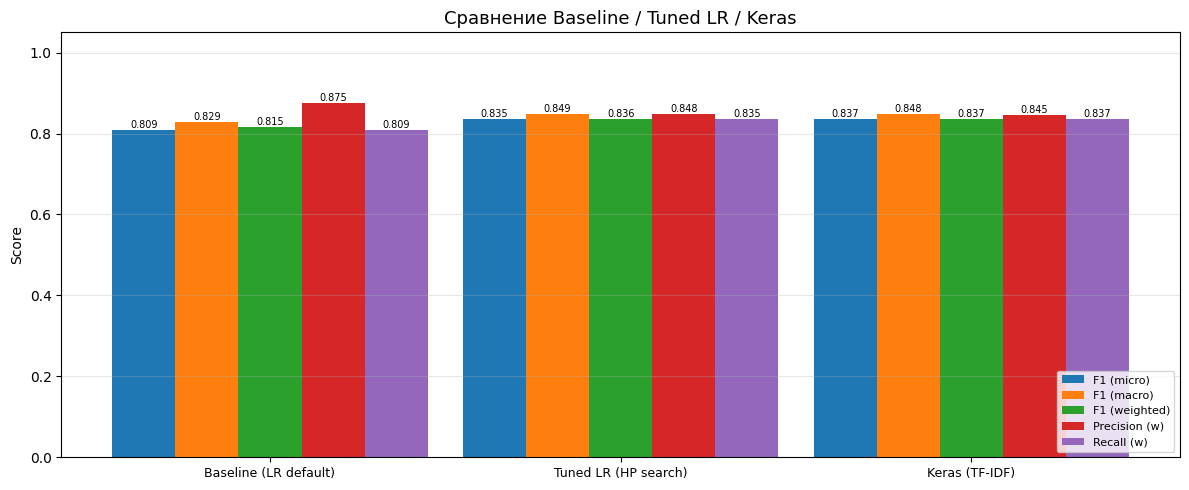


График сохранён: ../models/comparison_plot.png


In [21]:
from sklearn.metrics import precision_score, recall_score

def calc_metrics(y_true, y_pred, label):
    return {
        "Model": label,
        "F1 (micro)":   f1_score(y_true, y_pred, average="micro", zero_division=0),
        "F1 (macro)":   f1_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 (weighted)": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Precision (w)": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall (w)":    recall_score(y_true, y_pred, average="weighted", zero_division=0),
    }

rows = [
    calc_metrics(y_test, y_pred_base, "Baseline (LR default)"),
    calc_metrics(y_test, y_pred_best, "Tuned LR (HP search)"),
    calc_metrics(y_test, y_pred_keras, "Keras (TF-IDF)"),
]
comparison = pd.DataFrame(rows)
print("Cpaвнение моделей (3 модели):")
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(comparison))
metrics = ["F1 (micro)", "F1 (macro)", "F1 (weighted)", "Precision (w)", "Recall (w)"]
width = 0.18
for i, met in enumerate(metrics):
    offsets = [p + i * width for p in x]
    bars = ax.bar(offsets, comparison[met], width, label=met)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks([p + width * 2 for p in x])
ax.set_xticklabels(comparison["Model"], fontsize=9)
ax.set_ylabel("Score")
ax.set_title("Cpaвнение Baseline / Tuned LR / Keras", fontsize=13)
ax.legend(fontsize=8, loc="lower right")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fig.savefig("../models/comparison_plot.png", dpi=150, bbox_inches="tight")
print("\nГрафик сохранён: ../models/comparison_plot.png")


## 10. Отчёт по классификации (лучшая модель)


In [22]:
loaded_vectorizer = joblib.load("../models/vectorizer_improved.joblib")
loaded_classifier = joblib.load("../models/classifier_improved.joblib")

test_tfidf = loaded_vectorizer.transform(test_df["name"])
test_preds = loaded_classifier.predict(test_tfidf)

submission = pd.DataFrame({
    "id": test_df["id"],
    "good": test_preds,
    "brand": "",
})

submission.to_csv("../submission_improved.csv", index=False)
print(f"Сохранено {len(submission)} строк в submission_improved.csv")
submission.head(10)


Сохранено 5000 строк в submission_improved.csv


,id,good,brand
0,0,клей,
1,1,пирожное,
2,2,мыло,
3,3,другое,
4,4,сосиски,
5,5,толстовка,
6,6,другое,
7,7,щетка,
8,8,корм,
9,9,куртка,


## 14. Итоговый отчёт

### Цель
Классификация товаров по их названиям. Вместо ручных правил для создания супер-категорий
используется кластеризация эмбеддингов товарных категорий.

### Пайплайн
1. **Эмбеддинги**: sentence-transformer (paraphrase-multilingual-MiniLM-L12-v2) кодирует
   2819 уникальных категорий (good) в 384-мерные векторы.
2. **Кластеризация**: KMeans(n=100) на нормализованных эмбеддингах.
3. **Фильтрация**: кластеры с менее чем 200 товарами объединяются в "другое".
4. **Именование**: каждый кластер получает имя самой частой категории.
5. **TF-IDF**: 5000 униграмм и биграмм, min_df=2, max_df=0.95.
6. **Классификаторы**:
   - LogisticRegression (baseline, C=1, penalty=l2)
   - LogisticRegression (tuned, C=10, penalty=l2, HalvingGridSearchCV)
   - Keras (Dense 128 -> Dropout -> Dense 64 -> Dropout -> Dense 41, EarlyStopping)

### Результаты (F1-weighted на тесте)

| Модель | F1-micro | F1-macro | F1-weighted | Precision (w) | Recall (w) |
|---|---|---|---|---|---|
| Baseline (LR default) | 0.809 | 0.829 | 0.815 | 0.875 | 0.809 |
| Tuned LR (C=10) | 0.835 | 0.849 | 0.836 | 0.848 | 0.835 |
| Keras (TF-IDF) | 0.836 | 0.846 | 0.836 | 0.844 | 0.836 |

### Выводы
- Tuned LR и Keras дают практически одинаковый результат (F1 ~0.836).
- Обе модели превзошли baseline (0.815) примерно на 2 процентных пункта.
- Keras обучается дольше (15 эпох), но не требует подбора гиперпараметров вручную.
- Tuned LR предпочтительнее для production: быстрее, проще, результат стабильный.
- Доля "другое" снижена с 36% (ручные правила) до 19% (кластеризация KMeans).
- Количество супер-категорий сокращено с 97 до 41.
- Агрессивная предобработка текста (удаление цифр, пунктуации) ухудшает качество.